# Lab 02 — Chapter 12: N-gram experiments

Notebook độc lập: chạy các cell theo thứ tự để thực hiện thống kê corpus, MLE/Laplace, perplexity, dự đoán từ tiếp theo và sentence ranking.

## 1. Import và cấu hình thí nghiệm

In [1]:
from collections import Counter, defaultdict
from math import exp, inf, log
from pathlib import Path
from typing import Sequence
import json
import re

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'lab2').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'lab2').is_dir():
    raise FileNotFoundError('Không tìm thấy thư mục lab2.')

DATASET_PATH = PROJECT_ROOT / 'data' / 'c4-train.00000-of-01024-30K.json' / 'c4-train.00000-of-01024-30K.json'
DOCUMENT_LIMIT = 10_000
TRAIN_SHARE = 0.80
VALIDATION_SHARE = 0.10
ORDERS = (1, 2, 3)
MODEL_NAMES = {1: 'unigram', 2: 'bigram', 3: 'trigram'}
SMOOTHING_OPTIONS = (('mle', False), ('laplace', True))
UNKNOWN_TOKEN = '<unk>'
TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?")
SENTENCE_BOUNDARY_PATTERN = re.compile(r'[.!?]+(?:\s+|$)')
PREDICTION_CONTEXTS = ('the cat', 'natural language', 'machine learning', 'data science', 'artificial intelligence')
RANKING_CONTEXT = 'machine learning'
RANKING_CANDIDATES = ('is useful for natural language processing', 'banana computer quickly', 'studies language models')


## 2. Tải corpus và đếm n-gram

In [2]:
def tokenize(text: str) -> list[str]:
    """Chuẩn hóa một đoạn văn bản thành danh sách token chữ thường."""
    return TOKEN_PATTERN.findall(text.lower())


def load_sentences(dataset_path: Path, document_limit: int) -> tuple[int, list[list[str]]]:
    """Đọc tối đa document_limit documents JSONL và tách thành câu có token."""
    document_count = 0
    sentences: list[list[str]] = []
    with dataset_path.open(encoding='utf-8') as dataset_file:
        for line in dataset_file:
            document = json.loads(line).get('text', '')
            if not isinstance(document, str) or not document.strip():
                continue
            sentence_texts = SENTENCE_BOUNDARY_PATTERN.split(document)
            sentences.extend(tokens for tokens in map(tokenize, sentence_texts) if tokens)
            document_count += 1
            if document_count >= document_limit:
                break
    if not sentences:
        raise ValueError('Corpus không có câu hợp lệ.')
    return document_count, sentences


def split_sentences(sentences: Sequence[Sequence[str]]) -> tuple[list[list[str]], list[list[str]], list[list[str]]]:
    """Chia tuần tự câu thành ba tập train, validation và test theo tỉ lệ 80/10/10."""
    if len(sentences) < len(ORDERS):
        raise ValueError('Cần ít nhất ba câu để chia dữ liệu.')
    train_end = max(1, int(len(sentences) * TRAIN_SHARE))
    validation_end = min(len(sentences) - 1, max(train_end + 1, int(len(sentences) * (TRAIN_SHARE + VALIDATION_SHARE))))
    return [list(row) for row in sentences[:train_end]], [list(row) for row in sentences[train_end:validation_end]], [list(row) for row in sentences[validation_end:]]


def count_ngrams(corpus: Sequence[Sequence[str]], order: int) -> Counter[tuple[str, ...]]:
    """Đếm mọi n-gram liên tiếp có một order xác định trong corpus."""
    counts: Counter[tuple[str, ...]] = Counter()
    for sentence in corpus:
        for start_index in range(max(0, len(sentence) - order + 1)):
            counts[tuple(sentence[start_index:start_index + order])] += 1
    return counts


## 3. Cài đặt unigram, bigram và trigram language model

In [3]:
class NGramLanguageModel:
    """Language model n-gram tự cài đặt với lựa chọn MLE hoặc Laplace smoothing."""

    def __init__(self, order: int, smoothing: bool = False) -> None:
        """Khởi tạo model theo order và trạng thái smoothing."""
        if order not in ORDERS:
            raise ValueError(f'Order không hợp lệ: {order}.')
        self.order = order
        self.smoothing = smoothing
        self.vocabulary: set[str] = set()
        self.context_counts: Counter[tuple[str, ...]] = Counter()
        self.continuation_counts: dict[tuple[str, ...], Counter[str]] = defaultdict(Counter)

    def fit(self, corpus: Sequence[Sequence[str]]) -> 'NGramLanguageModel':
        """Huấn luyện model bằng count của mọi context tối đa order - 1."""
        self.vocabulary = {token for sentence in corpus for token in sentence}
        if not self.vocabulary:
            raise ValueError('Training corpus không có token.')
        self.vocabulary.add(UNKNOWN_TOKEN)
        for sentence in corpus:
            for token_index, word in enumerate(sentence):
                for context_size in range(min(self.order - 1, token_index) + 1):
                    context = tuple(sentence[token_index - context_size:token_index])
                    self.context_counts[context] += 1
                    self.continuation_counts[context][word] += 1
        return self

    def probability(self, context: Sequence[str], word: str) -> float:
        """Trả về P(word | context) theo MLE hoặc Laplace smoothing."""
        maximum_context_size = self.order - 1
        context_suffix = list(context)[-maximum_context_size:] if maximum_context_size else []
        normalized_context = tuple(token if token in self.vocabulary else UNKNOWN_TOKEN for token in context_suffix)
        normalized_word = word if word in self.vocabulary else UNKNOWN_TOKEN
        context_count = self.context_counts[normalized_context]
        word_count = self.continuation_counts[normalized_context][normalized_word]
        if self.smoothing:
            return (word_count + 1) / (context_count + len(self.vocabulary))
        return word_count / context_count if context_count else 0.0

    def sentence_log_probability(self, sentence: Sequence[str]) -> float:
        """Tính log xác suất câu để tránh numerical underflow."""
        total_log_probability = 0.0
        for token_index, word in enumerate(sentence):
            context = sentence[max(0, token_index - self.order + 1):token_index]
            conditional_probability = self.probability(context, word)
            if conditional_probability == 0.0:
                return float('-inf')
            total_log_probability += log(conditional_probability)
        return total_log_probability

    def perplexity(self, corpus: Sequence[Sequence[str]]) -> float:
        """Tính perplexity theo log probability trung bình trên mỗi token."""
        token_count = sum(len(sentence) for sentence in corpus)
        if token_count == 0:
            raise ValueError('Evaluation corpus không có token.')
        corpus_log_probability = sum(self.sentence_log_probability(sentence) for sentence in corpus)
        return inf if corpus_log_probability == float('-inf') else exp(-corpus_log_probability / token_count)

    def predict_next(self, context: str, limit: int) -> list[tuple[str, float]]:
        """Xếp hạng limit từ tiếp theo có xác suất cao nhất sau context."""
        context_tokens = tokenize(context)
        candidates = ((word, self.probability(context_tokens, word)) for word in self.vocabulary if word != UNKNOWN_TOKEN)
        return sorted(candidates, key=lambda item: (-item[1], item[0]))[:limit]

    def continuation_log_probability(self, context: str, continuation: str) -> float:
        """Tính log P(continuation | context) để phục vụ sentence ranking."""
        history = tokenize(context)
        total_log_probability = 0.0
        for word in tokenize(continuation):
            conditional_probability = self.probability(history, word)
            if conditional_probability == 0.0:
                return float('-inf')
            total_log_probability += log(conditional_probability)
            history.append(word)
        return total_log_probability


## 4. Chạy thí nghiệm: thống kê, smoothing, perplexity và ứng dụng

In [4]:
document_count, sentences = load_sentences(DATASET_PATH, DOCUMENT_LIMIT)
training_set, validation_set, test_set = split_sentences(sentences)
evaluation_sets = (('train', training_set), ('validation', validation_set), ('test', test_set))

corpus_statistics = {
    'documents': document_count,
    'sentences': len(sentences),
    'tokens': sum(len(sentence) for sentence in sentences),
    'vocabulary': len({token for sentence in sentences for token in sentence}),
}
ngram_statistics = []
frequency_distributions = {}
for order in ORDERS:
    ngram_counts = count_ngrams(sentences, order)
    ngram_statistics.append({
        'model': MODEL_NAMES[order],
        'unique_ngrams': len(ngram_counts),
        'hapax_ngrams': sum(count == 1 for count in ngram_counts.values()),
    })
    frequency_distributions[MODEL_NAMES[order]] = Counter(ngram_counts.values())

perplexity_results = []
application_model = None
for order in ORDERS:
    for smoothing_name, smoothing_enabled in SMOOTHING_OPTIONS:
        model = NGramLanguageModel(order, smoothing_enabled).fit(training_set)
        for split_name, evaluation_set in evaluation_sets:
            perplexity_results.append({
                'model': MODEL_NAMES[order],
                'smoothing': smoothing_name,
                'split': split_name,
                'perplexity': model.perplexity(evaluation_set),
            })
        if order == max(ORDERS) and smoothing_enabled:
            application_model = model

if application_model is None:
    raise RuntimeError('Không khởi tạo được model dùng cho application.')

prediction_results = [
    {'context': context, 'predictions': application_model.predict_next(context, limit=len(ORDERS) + 2)}
    for context in PREDICTION_CONTEXTS
]
ranking_results = sorted(
    ((candidate, application_model.continuation_log_probability(RANKING_CONTEXT, candidate)) for candidate in RANKING_CANDIDATES),
    key=lambda item: item[1],
    reverse=True,
)

print(f'Documents: {document_count:,}')
print(f'Sentences: {len(sentences):,}')
print(f'Tokens: {corpus_statistics["tokens"]:,}')
ngram_statistics


Documents: 10,000
Sentences: 205,350
Tokens: 3,591,577


[{'model': 'unigram', 'unique_ngrams': 92915, 'hapax_ngrams': 41586},
 {'model': 'bigram', 'unique_ngrams': 1134566, 'hapax_ngrams': 829272},
 {'model': 'trigram', 'unique_ngrams': 2330239, 'hapax_ngrams': 2053200}]

## 5. Xem perplexity, dự đoán, ranking và frequency distribution

Perplexity:


[{'model': 'unigram',
  'smoothing': 'mle',
  'split': 'train',
  'perplexity': 1848.4675831072},
 {'model': 'unigram',
  'smoothing': 'mle',
  'split': 'validation',
  'perplexity': inf},
 {'model': 'unigram', 'smoothing': 'mle', 'split': 'test', 'perplexity': inf},
 {'model': 'unigram',
  'smoothing': 'laplace',
  'split': 'train',
  'perplexity': 1857.6346368763238},
 {'model': 'unigram',
  'smoothing': 'laplace',
  'split': 'validation',
  'perplexity': 1992.4122081600128},
 {'model': 'unigram',
  'smoothing': 'laplace',
  'split': 'test',
  'perplexity': 2019.1579861319642},
 {'model': 'bigram',
  'smoothing': 'mle',
  'split': 'train',
  'perplexity': 139.39152431426666},
 {'model': 'bigram',
  'smoothing': 'mle',
  'split': 'validation',
  'perplexity': inf},
 {'model': 'bigram', 'smoothing': 'mle', 'split': 'test', 'perplexity': inf},
 {'model': 'bigram',
  'smoothing': 'laplace',
  'split': 'train',
  'perplexity': 5156.916949707187},
 {'model': 'bigram',
  'smoothing': 'lapla

Next-word prediction:


[{'context': 'the cat',
  'predictions': [('house', 3.6708922715481375e-05),
   ('didn', 2.447261514365425e-05),
   ('had', 2.447261514365425e-05),
   ('home', 2.447261514365425e-05),
   ('houses', 2.447261514365425e-05)]},
 {'context': 'natural language',
  'predictions': [('processing', 2.447561005458061e-05),
   ('toolkit', 2.447561005458061e-05),
   ('a', 1.2237805027290306e-05),
   ("a's", 1.2237805027290306e-05),
   ("a'val", 1.2237805027290306e-05)]},
 {'context': 'machine learning',
  'predictions': [('and', 9.786291851688747e-05),
   ('based', 7.33971888876656e-05),
   ('approaches', 6.116432407305467e-05),
   ('models', 6.116432407305467e-05),
   ('to', 4.893145925844374e-05)]},
 {'context': 'data science',
  'predictions': [('and', 2.4474112507495196e-05),
   ('executives', 2.4474112507495196e-05),
   ('in', 2.4474112507495196e-05),
   ('methods', 2.4474112507495196e-05),
   ('more', 2.4474112507495196e-05)]},
 {'context': 'artificial intelligence',
  'predictions': [('ai', 

Sentence ranking (log probability):


[('banana computer quickly', -33.93329668861328),
 ('studies language models', -33.93329668861328),
 ('is useful for natural language processing', -64.87133832918362)]

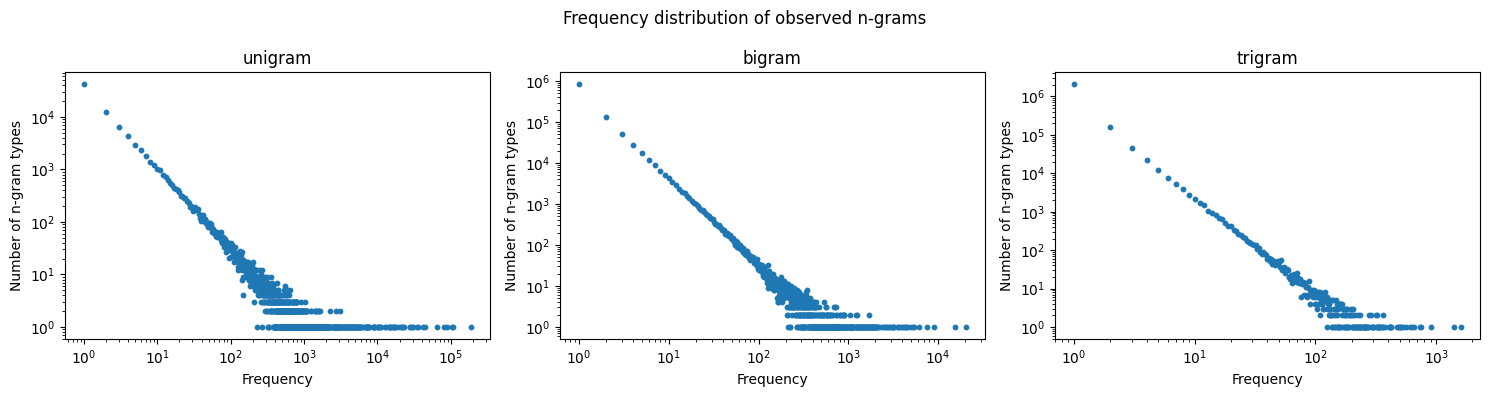

In [5]:
print('Perplexity:')
display(perplexity_results)
print('Next-word prediction:')
display(prediction_results)
print('Sentence ranking (log probability):')
display(ranking_results)

import matplotlib.pyplot as plt

figure, axes = plt.subplots(nrows=1, ncols=len(ORDERS), figsize=(15, 4))
for axis, order in zip(axes, ORDERS):
    distribution = frequency_distributions[MODEL_NAMES[order]]
    axis.scatter(list(distribution), list(distribution.values()), s=10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.set_title(MODEL_NAMES[order])
    axis.set_xlabel('Frequency')
    axis.set_ylabel('Number of n-gram types')
figure.suptitle('Frequency distribution of observed n-grams')
figure.tight_layout()
plt.show()
